In [ ]:
# we need to run on a py file instead of a jupyter notebook otherwise multiprocessing will not work properly
from agent import Agent, pit
from model_files.SLPolicyValueGPU import SLPolicyValueNetwork
import torch
import chess


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1 = SLPolicyValueNetwork().to(device)
model1.load_state_dict(torch.load("LGB_2400ELO_70k.pth", map_location=torch.device("cuda"))["model"])
agent = Agent(policy_value_network=model1, c_puct=0.0, dirichlet_alpha=0.3, dirichlet_epsilon=0.3)
# epsilon is set to 0 for no noise

mcts_policy_temp = 1.0 #setting temp to 1 means no temperature (temperature for policy)
mcts_temp = 0.5 # <1 means we boost the uct scores of top moves
sims = 3000

move: g2g4, count: 379.0, ev: 0.15623323619365692
move: c2c4, count: 214.0, ev: 0.12168723344802856
move: b2b3, count: 210.0, ev: 0.12200283259153366
move: c2c3, count: 201.0, ev: 0.11897946149110794
move: f2f3, count: 193.0, ev: 0.11592357605695724
move: e2e3, count: 185.0, ev: 0.12250620126724243
move: g2g3, count: 183.0, ev: 0.12053210288286209
move: b2b4, count: 178.0, ev: 0.11061808466911316
move: h2h4, count: 176.0, ev: 0.12553513050079346
move: d2d4, count: 156.0, ev: 0.11390044540166855
move: d2d3, count: 153.0, ev: 0.11631519347429276
move: b1a3, count: 134.0, ev: 0.1068776473402977
move: g1h3, count: 129.0, ev: 0.10474106669425964
move: h2h3, count: 128.0, ev: 0.11091497540473938
move: f2f4, count: 106.0, ev: 0.09877930581569672
move: e2e4, count: 97.0, ev: 0.10806266218423843
move: a2a3, count: 84.0, ev: 0.1079154685139656
move: g1f3, count: 83.0, ev: 0.09374649077653885
move: a2a4, count: 6.0, ev: 0.06877470016479492
move: b1c3, count: 4.0, ev: 0.07060932368040085
final eva

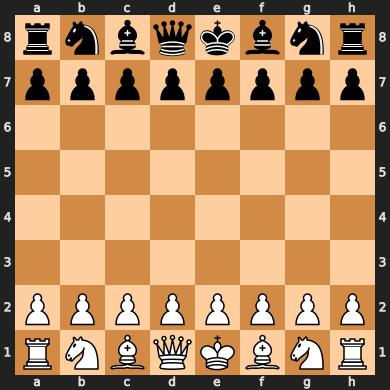

In [ ]:
# Test evaluations

# should be about equal
board = chess.Board()
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp, mcts_temperature=mcts_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: d3h3, count: 129.0, ev: 0.8189235925674438
move: a1b2, count: 129.0, ev: 0.838287353515625
move: d3e3, count: 125.0, ev: 0.8060021996498108
move: d3c3, count: 124.0, ev: 0.819099485874176
move: d3e2, count: 121.0, ev: 0.7779313325881958
move: d3a6, count: 119.0, ev: 0.800851583480835
move: d3f5, count: 118.0, ev: 0.7930269241333008
move: d3c2, count: 118.0, ev: 0.7939836978912354
move: d3f3, count: 117.0, ev: 0.7974097728729248
move: d3a3, count: 117.0, ev: 0.8137692213058472
move: d3c4, count: 116.0, ev: 0.7860955595970154
move: d3d1, count: 116.0, ev: 0.79715496301651
move: d3b5, count: 115.0, ev: 0.8292529582977295
move: a1a2, count: 113.0, ev: 0.8433310985565186
move: a1b1, count: 112.0, ev: 0.8403775095939636
move: d3d8, count: 110.0, ev: 0.7935390472412109
move: d3g3, count: 109.0, ev: 0.7869371175765991
move: d3e4, count: 106.0, ev: 0.7795024514198303
move: d3b1, count: 104.0, ev: 0.782302975654602
move: d3b3, count: 103.0, ev: 0.7750208973884583
move: d3f1, count: 103.0, 

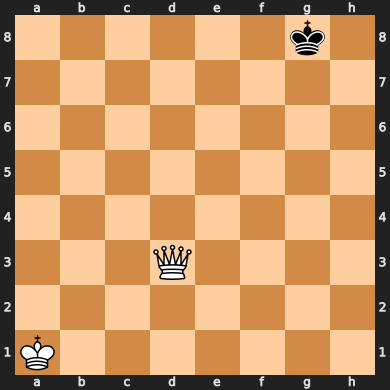

In [ ]:
board = chess.Board("6k1/8/8/8/8/3Q4/8/K7 w - - 0 1")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: g8h8, count: 922.0, ev: -0.801866888999939
move: g8f8, count: 726.0, ev: -0.8212622404098511
move: g8g7, count: 349.0, ev: -0.8164098262786865
move: g8f7, count: 2.0, ev: -0.8739526867866516
final eval:  -0.8018669076829563
tested 4 moves out of  4
g8h8
initial evaluation:  -0.8520120978355408


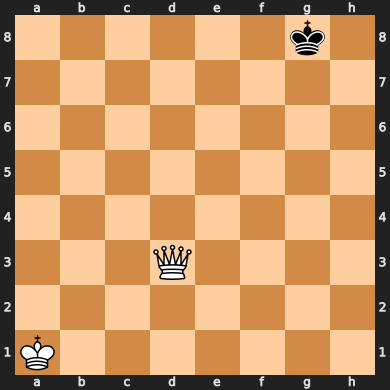

In [ ]:
# should be negative (losing)
board = chess.Board("6k1/8/8/8/8/3Q4/8/K7 b - - 0 1")
print(agent.select_move(game_state=board, num_simulations=2000, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp)y_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: d1f3, count: 149.0, ev: 0.11660370230674744
move: f2f3, count: 134.0, ev: 0.10682885348796844
move: c3d5, count: 130.0, ev: 0.13063371181488037
move: g2g3, count: 120.0, ev: 0.09027964621782303
move: d1h5, count: 117.0, ev: 0.07848089188337326
move: f1d3, count: 113.0, ev: 0.07559337466955185
move: d1e2, count: 111.0, ev: 0.10775768011808395
move: a2a4, count: 110.0, ev: 0.09031887352466583
move: b2b4, count: 109.0, ev: 0.11883849650621414
move: a2a3, count: 107.0, ev: 0.10693343728780746
move: g1f3, count: 106.0, ev: 0.08930818736553192
move: b2b3, count: 101.0, ev: 0.12540562450885773
move: d2d4, count: 101.0, ev: 0.11497119814157486
move: a1b1, count: 99.0, ev: 0.08069217950105667
move: d2d3, count: 99.0, ev: 0.11695545166730881
move: g1e2, count: 95.0, ev: 0.07717011123895645
move: g2g4, count: 94.0, ev: 0.10035362839698792
move: c3b5, count: 93.0, ev: 0.092267706990242
move: g1h3, count: 93.0, ev: 0.07567287981510162
move: h2h4, count: 93.0, ev: 0.08109928667545319
move: f1e

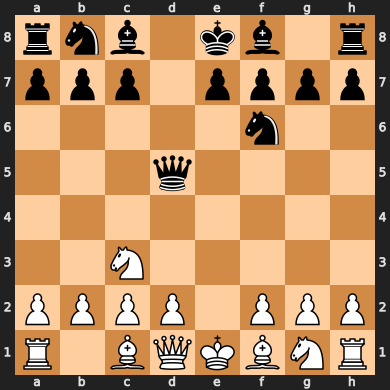

In [ ]:
# should be positive (c3d5, somewhat winning)
board = chess.Board("rnb1kb1r/ppp1pppp/5n2/3q4/8/2N5/PPPP1PPP/R1BQKBNR w KQkq - 2 4")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp)y_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: d8d4, count: 319.0, ev: 0.07059282064437866
move: c8e6, count: 160.0, ev: -0.05339642986655235
move: c7c6, count: 131.0, ev: -0.047584742307662964
move: b8c6, count: 124.0, ev: -0.04987073317170143
move: e7e5, count: 119.0, ev: -0.06058211252093315
move: c7c5, count: 119.0, ev: -0.04056505113840103
move: b7b6, count: 116.0, ev: -0.06506500393152237
move: b7b5, count: 111.0, ev: -0.06646963208913803
move: e7e6, count: 110.0, ev: -0.06751919537782669
move: h7h6, count: 106.0, ev: -0.07235731929540634
move: a7a5, count: 104.0, ev: -0.06674374639987946
move: f6e4, count: 103.0, ev: -0.07154638320207596
move: h8g8, count: 101.0, ev: -0.08068075776100159
move: c8g4, count: 101.0, ev: -0.07691773772239685
move: a7a6, count: 101.0, ev: -0.07423911243677139
move: d8d6, count: 100.0, ev: -0.06815794855356216
move: c8f5, count: 99.0, ev: -0.06501776725053787
move: d8d7, count: 94.0, ev: -0.0742916613817215
move: f6g4, count: 88.0, ev: -0.07589176297187805
move: b8a6, count: 87.0, ev: -0.069

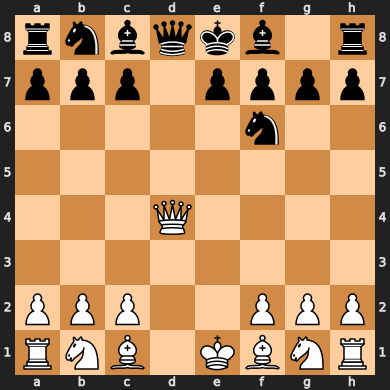

In [ ]:
# should be positive (d8d4, somewhat winning)
board = chess.Board("rnbqkb1r/ppp1pppp/5n2/8/3Q4/8/PPP2PPP/RNB1KBNR b KQkq - 2 4")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: g1f3, count: 154.0, ev: -0.027912428602576256
move: g1e2, count: 148.0, ev: -0.04877057299017906
move: f1e2, count: 145.0, ev: -0.13752123713493347
move: c1e3, count: 143.0, ev: -0.09447876363992691
move: c2c3, count: 136.0, ev: -0.040450677275657654
move: f1d3, count: 128.0, ev: -0.14425596594810486
move: b2b3, count: 123.0, ev: -0.10762762278318405
move: b1c3, count: 115.0, ev: -0.11479502171278
move: b2b4, count: 113.0, ev: -0.15627694129943848
move: f2f3, count: 107.0, ev: -0.07234814763069153
move: a2a3, count: 106.0, ev: -0.14502890408039093
move: b1a3, count: 105.0, ev: -0.1462390422821045
move: h2h3, count: 105.0, ev: -0.12349072843790054
move: c2c4, count: 103.0, ev: -0.16129063069820404
move: f1c4, count: 100.0, ev: -0.18499739468097687
move: b1d2, count: 100.0, ev: -0.13073962926864624
move: a2a4, count: 98.0, ev: -0.17892903089523315
move: e1e2, count: 96.0, ev: -0.18557895720005035
move: g2g3, count: 96.0, ev: -0.13067391514778137
move: h2h4, count: 96.0, ev: -0.1551

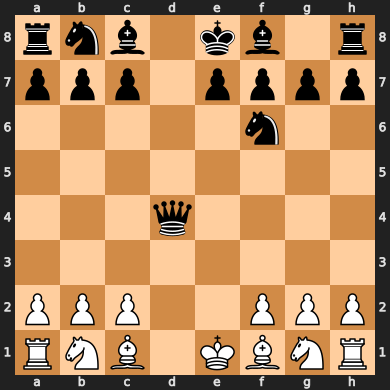

In [ ]:
# should be negative (after d8d4, somewhat losing)
board = chess.Board("rnb1kb1r/ppp1pppp/5n2/8/3q4/8/PPP2PPP/RNB1KBNR w KQkq - 0 5")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp)y_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: e6e7, count: 148.0, ev: 0.45358291268348694
move: b3d4, count: 108.0, ev: 0.04536305367946625
move: b3d2, count: 108.0, ev: 0.01405348815023899
move: h6h5, count: 107.0, ev: -0.028951482847332954
move: b3c5, count: 107.0, ev: 0.07243157923221588
move: e6f6, count: 102.0, ev: 0.08957646042108536
move: h6e3, count: 97.0, ev: -0.09567972272634506
move: h1g1, count: 96.0, ev: -0.09970953315496445
move: e6c6, count: 95.0, ev: -0.1393444836139679
move: h2g3, count: 94.0, ev: 0.05727379396557808
move: c2c4, count: 94.0, ev: -0.01671319082379341
move: b3a1, count: 90.0, ev: -0.07625888288021088
move: h6g5, count: 89.0, ev: -0.08187504857778549
move: e6e2, count: 88.0, ev: -0.08975517004728317
move: d3d4, count: 88.0, ev: -0.07737432420253754
move: a2a3, count: 86.0, ev: -0.07519655674695969
move: a2a4, count: 86.0, ev: -0.08486926555633545
move: e6d6, count: 85.0, ev: -0.09266280382871628
move: c2c3, count: 85.0, ev: -0.03513600677251816
move: b3a5, count: 83.0, ev: -0.061146579682826996

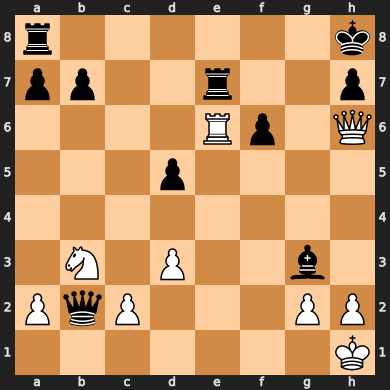

In [ ]:
# should be positive (e6e7, somewhat winning)
board = chess.Board("r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2b1/PqP3PP/7K w - - 0 25")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp)y_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: d7c6, count: 136.0, ev: -0.29701218008995056
move: g6g5, count: 124.0, ev: -0.34761494398117065
move: d8c8, count: 112.0, ev: -0.33228757977485657
move: b7b5, count: 110.0, ev: -0.4065861403942108
move: b7b6, count: 109.0, ev: -0.40537455677986145
move: d8f8, count: 102.0, ev: -0.3399903178215027
move: b8c7, count: 102.0, ev: -0.36902129650115967
move: d7g4, count: 97.0, ev: -0.411337286233902
move: d7a4, count: 97.0, ev: -0.3974013328552246
move: d6d5, count: 94.0, ev: -0.3760344386100769
move: a7a6, count: 94.0, ev: -0.44038131833076477
move: d8e8, count: 93.0, ev: -0.4134783446788788
move: d7f5, count: 92.0, ev: -0.431131511926651
move: d6f8, count: 90.0, ev: -0.48631107807159424
move: d6e7, count: 89.0, ev: -0.45554667711257935
move: h6h5, count: 88.0, ev: -0.43759456276893616
move: d7e6, count: 87.0, ev: -0.40402644872665405
move: d6f6, count: 87.0, ev: -0.45905306935310364
move: d6d4, count: 82.0, ev: -0.38496336340904236
move: d6c6, count: 80.0, ev: -0.4445274770259857
mov

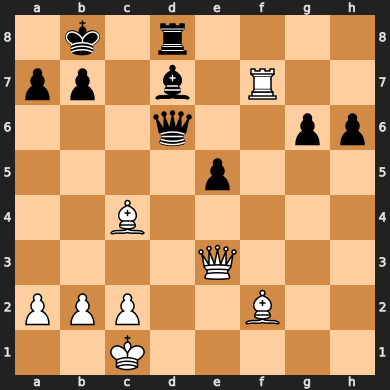

In [ ]:
# should be positive (d6d1, mate in 3)
board = chess.Board("1k1r4/pp1b1R2/3q2pp/4p3/2B5/4Q3/PPP2B2/2K5 b - - 0 1")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp)y_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: d7e6, count: 232.0, ev: -0.7035492658615112
move: d7b5, count: 182.0, ev: -0.775551974773407
move: d8f8, count: 179.0, ev: -0.7658613920211792
move: d7c6, count: 173.0, ev: -0.780512273311615
move: d7f5, count: 168.0, ev: -0.7737756371498108
move: d8c8, count: 166.0, ev: -0.7808389663696289
move: g6g5, count: 156.0, ev: -0.7809444665908813
move: d7e8, count: 145.0, ev: -0.7496852874755859
move: a7a6, count: 127.0, ev: -0.7957090735435486
move: d7c8, count: 126.0, ev: -0.7865651249885559
move: d7a4, count: 126.0, ev: -0.7923194169998169
move: d8e8, count: 124.0, ev: -0.7910923361778259
move: d7h3, count: 116.0, ev: -0.7951481938362122
move: d8h8, count: 115.0, ev: -0.8115821480751038
move: b8c8, count: 113.0, ev: -0.810933530330658
move: b7b5, count: 112.0, ev: -0.7926876544952393
move: b8c7, count: 111.0, ev: -0.8046748042106628
move: b7b6, count: 109.0, ev: -0.7989869713783264
move: h6h5, count: 102.0, ev: -0.7973136901855469
move: e5e4, count: 101.0, ev: -0.7910535931587219
mov

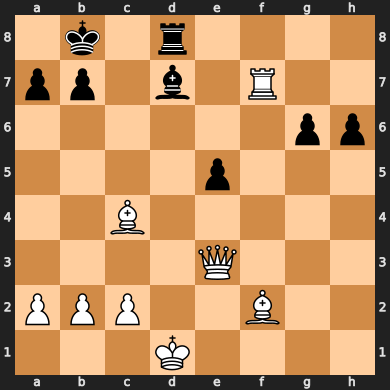

In [ ]:
# should be positive (d7g4, mate in 2)
board = chess.Board("1k1r4/pp1b1R2/6pp/4p3/2B5/4Q3/PPP2B2/3K4 b - - 0 2")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp)y_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: d1e1, count: 2926.0, ev: 0.22310732305049896
move: d1c1, count: 73.0, ev: 0.058000657707452774
final eval:  0.223107326895467
tested 2 moves out of  2
d1e1
initial evaluation:  0.6811873912811279


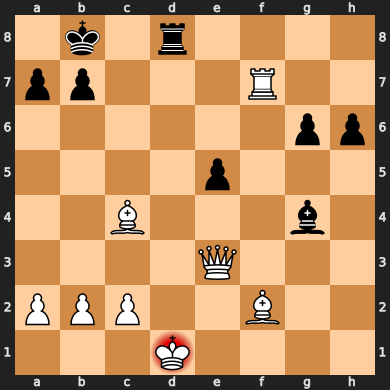

In [ ]:
# should be negative (d7g4, mate in 1 coming)
board = chess.Board("1k1r4/pp3R2/6pp/4p3/2B3b1/4Q3/PPP2B2/3K4 w - - 1 3")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp)y_temp))
print("initial evaluation: ",agent.evaluate_value(board.fen()))
board

move: d8d1, count: 932.0, ev: 1.0
move: g4e6, count: 116.0, ev: -0.7102160453796387
move: g6g5, count: 92.0, ev: -0.7329424023628235
move: b8a8, count: 91.0, ev: -0.7213791012763977
move: d8f8, count: 87.0, ev: -0.7418050169944763
move: d8d5, count: 86.0, ev: -0.7257212400436401
move: b7b5, count: 85.0, ev: -0.7394633293151855
move: d8d3, count: 82.0, ev: -0.7415398955345154
move: e5e4, count: 81.0, ev: -0.7414320111274719
move: g4f5, count: 80.0, ev: -0.7505618333816528
move: b7b6, count: 80.0, ev: -0.760596752166748
move: g4f3, count: 79.0, ev: -0.7406611442565918
move: g4h3, count: 78.0, ev: -0.7652745246887207
move: g4e2, count: 77.0, ev: -0.7504146099090576
move: a7a6, count: 76.0, ev: -0.7150834798812866
move: d8d2, count: 74.0, ev: -0.7167145013809204
move: d8e8, count: 72.0, ev: -0.7616757750511169
move: d8c8, count: 69.0, ev: -0.7408707737922668
move: g4c8, count: 68.0, ev: -0.7517447471618652
move: d8d4, count: 65.0, ev: -0.7397990822792053
move: g4h5, count: 64.0, ev: -0.766

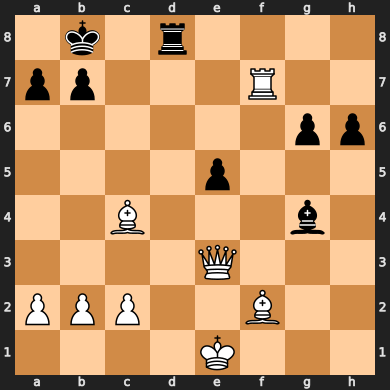

In [ ]:
# should be positive (d8d1, mate in 1)
board = chess.Board("1k1r4/pp3R2/6pp/4p3/2B3b1/4Q3/PPP2B2/4K3 b - - 2 3")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp)y_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board

move: f6g4, count: 148.0, ev: -0.07544838637113571
move: d8c7, count: 146.0, ev: -0.051803648471832275
move: d7d6, count: 145.0, ev: -0.0661701038479805
move: e7e6, count: 144.0, ev: -0.08713165670633316
move: f6d5, count: 138.0, ev: -0.08302485197782516
move: f6h5, count: 134.0, ev: -0.08006991446018219
move: a7a6, count: 133.0, ev: -0.09610465168952942
move: d8b6, count: 130.0, ev: -0.08669227361679077
move: c6d4, count: 129.0, ev: -0.0772114247083664
move: h7h6, count: 125.0, ev: -0.08797433972358704
move: f6e4, count: 123.0, ev: -0.08089606463909149
move: c6e5, count: 123.0, ev: -0.05511252209544182
move: d8a5, count: 122.0, ev: -0.08718416839838028
move: d7d5, count: 120.0, ev: -0.08555862307548523
move: h8g8, count: 117.0, ev: -0.08317025750875473
move: f6g8, count: 116.0, ev: -0.09420452266931534
move: c6b4, count: 116.0, ev: -0.10283491015434265
move: c6b8, count: 114.0, ev: -0.1215771809220314
move: b7b6, count: 111.0, ev: -0.10550820082426071
move: c6a5, count: 103.0, ev: -0.

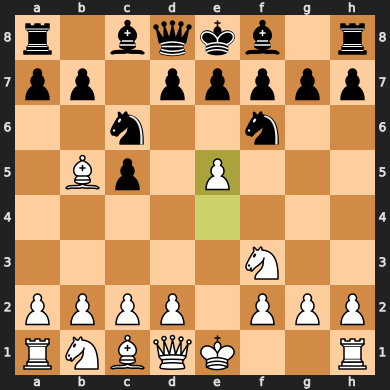

In [ ]:
#why does it take on e5??
board = chess.Board()
board.push_uci("e2e4")
board.push_uci("c7c5")
board.push_uci("g1f3")
board.push_uci("b8c6")
board.push_uci("f1b5")
board.push_uci("g8f6")
board.push_uci("e4e5")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp)y_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board


move: c2c4, count: 191.0, ev: 0.09423687309026718
move: d1e2, count: 169.0, ev: 0.08206496387720108
move: b5c4, count: 146.0, ev: 0.07078573107719421
move: e1g1, count: 145.0, ev: 0.07714852690696716
move: d2d4, count: 145.0, ev: 0.08583167940378189
move: b1c3, count: 140.0, ev: 0.0713782012462616
move: g2g3, count: 140.0, ev: 0.07103417068719864
move: d2d3, count: 132.0, ev: 0.07462108880281448
move: b5c6, count: 123.0, ev: 0.07539742439985275
move: c2c3, count: 123.0, ev: 0.0834435522556305
move: b5d3, count: 111.0, ev: 0.058865033090114594
move: h1g1, count: 111.0, ev: 0.06833279132843018
move: h2h3, count: 108.0, ev: 0.06206953525543213
move: f3g5, count: 103.0, ev: 0.06745142489671707
move: b2b3, count: 101.0, ev: 0.07107401639223099
move: e5e6, count: 97.0, ev: 0.053260259330272675
move: h2h4, count: 96.0, ev: 0.07113279402256012
move: f3h4, count: 89.0, ev: 0.05572855845093727
move: b5e2, count: 86.0, ev: 0.05047585070133209
move: e1f1, count: 83.0, ev: 0.055828757584095
move: h

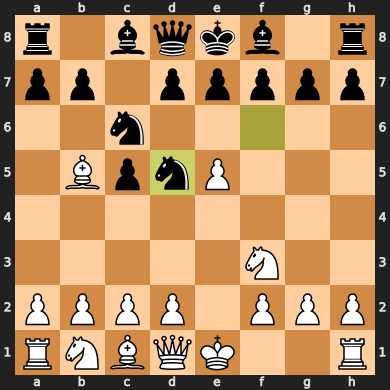

In [ ]:
# clearly worse for black?
board = chess.Board()
board.push_uci("e2e4")
board.push_uci("c7c5")
board.push_uci("g1f3")
board.push_uci("b8c6")
board.push_uci("f1b5")
board.push_uci("g8f6")
board.push_uci("e4e5")
board.push_uci("f6d5")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board


move: d5f4, count: 142.0, ev: -0.05489574745297432
move: d5b4, count: 139.0, ev: -0.07616201788187027
move: e7e6, count: 136.0, ev: -0.08003077656030655
move: d8c7, count: 132.0, ev: -0.10789427906274796
move: d5c3, count: 132.0, ev: -0.08458664268255234
move: h7h6, count: 130.0, ev: -0.10833393782377243
move: d5b6, count: 121.0, ev: -0.10684579610824585
move: g7g6, count: 119.0, ev: -0.16692587733268738
move: h8g8, count: 118.0, ev: -0.13333182036876678
move: c6b4, count: 118.0, ev: -0.10812664031982422
move: a7a6, count: 118.0, ev: -0.11229173094034195
move: c6d4, count: 114.0, ev: -0.08017187565565109
move: d7d6, count: 114.0, ev: -0.14184707403182983
move: c6a5, count: 113.0, ev: -0.12836240231990814
move: d5f6, count: 110.0, ev: -0.10792426764965057
move: d5e3, count: 108.0, ev: -0.09570349752902985
move: c6e5, count: 105.0, ev: -0.08185689896345139
move: a8b8, count: 102.0, ev: -0.14603587985038757
move: g7g5, count: 100.0, ev: -0.12066416442394257
move: f7f5, count: 98.0, ev: -0

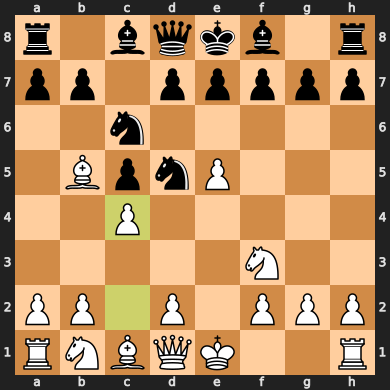

In [ ]:
# clearly worse for black?
board = chess.Board()
board.push_uci("e2e4")
board.push_uci("c7c5")
board.push_uci("g1f3")
board.push_uci("b8c6")
board.push_uci("f1b5")
board.push_uci("g8f6")
board.push_uci("e4e5")
board.push_uci("f6d5")
board.push_uci("c2c4")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board


move: d2d4, count: 153.0, ev: 0.09817393869161606
move: d2d3, count: 148.0, ev: 0.06541857123374939
move: d1e2, count: 138.0, ev: 0.05679604038596153
move: a2a3, count: 132.0, ev: 0.06808031350374222
move: b5c6, count: 130.0, ev: 0.06991931051015854
move: b2b3, count: 129.0, ev: 0.058443550020456314
move: e1g1, count: 123.0, ev: 0.06849755346775055
move: e1e2, count: 121.0, ev: 0.042676039040088654
move: b1c3, count: 120.0, ev: 0.05624626949429512
move: h1g1, count: 118.0, ev: 0.0536482110619545
move: d1b3, count: 118.0, ev: 0.043063271790742874
move: h2h3, count: 116.0, ev: 0.046676989644765854
move: e1f1, count: 114.0, ev: 0.0445411279797554
move: e5e6, count: 114.0, ev: 0.05117503181099892
move: g2g3, count: 113.0, ev: 0.03639741241931915
move: h2h4, count: 109.0, ev: 0.0402403324842453
move: h1f1, count: 108.0, ev: 0.04158538207411766
move: g2g4, count: 104.0, ev: 0.029452096670866013
move: a2a4, count: 101.0, ev: 0.025195516645908356
move: b5a4, count: 100.0, ev: 0.031226286664605

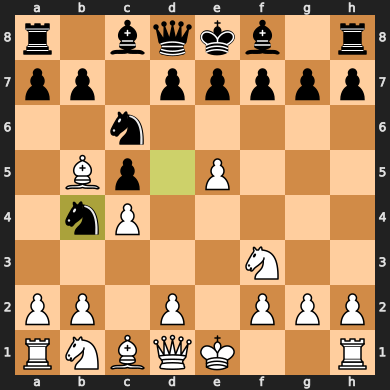

In [ ]:
board = chess.Board()
board.push_uci("e2e4")
board.push_uci("c7c5")
board.push_uci("g1f3")
board.push_uci("b8c6")
board.push_uci("f1b5")
board.push_uci("g8f6")
board.push_uci("e4e5")
board.push_uci("f6d5")
board.push_uci("c2c4")
board.push_uci("d5b4")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board


move: e2f3, count: 119.0, ev: 0.4831618666648865
move: d6e7, count: 94.0, ev: 0.20839551091194153
move: a1d1, count: 93.0, ev: 0.1877942681312561
move: a1b1, count: 90.0, ev: 0.17982995510101318
move: h2h3, count: 86.0, ev: 0.177590012550354
move: b6a4, count: 84.0, ev: 0.1613333523273468
move: b3f3, count: 82.0, ev: 0.31318697333335876
move: f1d1, count: 81.0, ev: 0.20862722396850586
move: g2g3, count: 81.0, ev: 0.22322435677051544
move: b6d7, count: 79.0, ev: 0.1767263561487198
move: e2a6, count: 79.0, ev: 0.19325892627239227
move: b6c4, count: 78.0, ev: 0.11447974294424057
move: b6c8, count: 75.0, ev: 0.18818475306034088
move: e2b5, count: 75.0, ev: 0.17031963169574738
move: f1c1, count: 74.0, ev: 0.24496789276599884
move: a1c1, count: 74.0, ev: 0.19048240780830383
move: f1e1, count: 73.0, ev: 0.1626398265361786
move: b3c3, count: 71.0, ev: 0.2167140692472458
move: b3d1, count: 71.0, ev: 0.12018822133541107
move: e2c4, count: 71.0, ev: 0.11795341223478317
move: e2d3, count: 71.0, ev

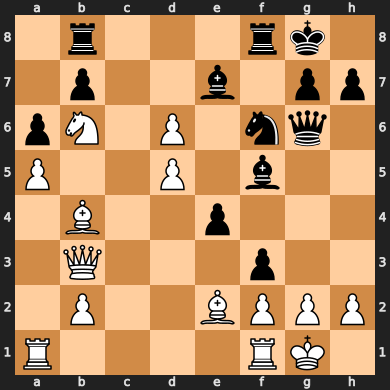

In [ ]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board

move: f3e4, count: 134.0, ev: 0.4724554717540741
move: d6e7, count: 122.0, ev: 0.4685690104961395
move: f3h3, count: 114.0, ev: 0.37600502371788025
move: f3g3, count: 114.0, ev: 0.38750922679901123
move: f3f6, count: 103.0, ev: 0.246036559343338
move: f3c3, count: 100.0, ev: 0.2846047878265381
move: f3d1, count: 100.0, ev: 0.20563539862632751
move: f3b3, count: 98.0, ev: 0.17188189923763275
move: f1e1, count: 97.0, ev: 0.34526532888412476
move: a1c1, count: 97.0, ev: 0.2765728533267975
move: f3a3, count: 91.0, ev: 0.22572745382785797
move: h2h3, count: 89.0, ev: 0.3390180170536041
move: f1d1, count: 83.0, ev: 0.3323625326156616
move: f3e2, count: 81.0, ev: 0.206975057721138
move: f1c1, count: 81.0, ev: 0.3065863847732544
move: f3e3, count: 78.0, ev: 0.18418751657009125
move: a1e1, count: 77.0, ev: 0.3100084662437439
move: b2b3, count: 76.0, ev: 0.28092753887176514
move: a1d1, count: 75.0, ev: 0.2779853343963623
move: h2h4, count: 75.0, ev: 0.26858246326446533
move: b6d7, count: 72.0, e

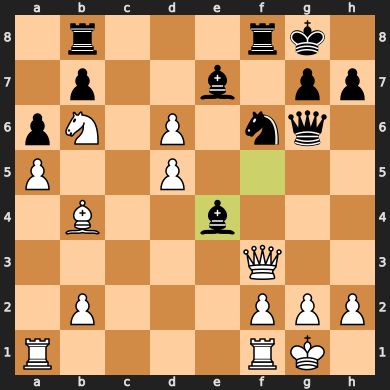

In [ ]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
board.push_uci("e2f3")
board.push_uci("e4f3")
board.push_uci("b3f3")
board.push_uci("f5e4")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board

move: e7d6, count: 272.0, ev: 0.26825231313705444
move: e4f3, count: 248.0, ev: 0.06548608839511871
move: f6d5, count: 162.0, ev: -0.1321622133255005
move: f6g4, count: 142.0, ev: -0.18130825459957123
move: f8d8, count: 122.0, ev: -0.33928534388542175
move: e7d8, count: 120.0, ev: -0.31705546379089355
move: b8e8, count: 116.0, ev: -0.20963095128536224
move: b8d8, count: 107.0, ev: -0.19852019846439362
move: e4d5, count: 95.0, ev: -0.3888876736164093
move: b8c8, count: 91.0, ev: -0.2891935110092163
move: g6f7, count: 90.0, ev: -0.39825746417045593
move: b8a8, count: 89.0, ev: -0.3815717399120331
move: f8e8, count: 86.0, ev: -0.400476336479187
move: g6f5, count: 85.0, ev: -0.3905077278614044
move: g6g4, count: 85.0, ev: -0.41478219628334045
move: f6d7, count: 82.0, ev: -0.2938472628593445
move: f8f7, count: 81.0, ev: -0.35256409645080566
move: g6g5, count: 80.0, ev: -0.36565083265304565
move: h7h6, count: 80.0, ev: -0.39245060086250305
move: f8c8, count: 73.0, ev: -0.40108782052993774
mo

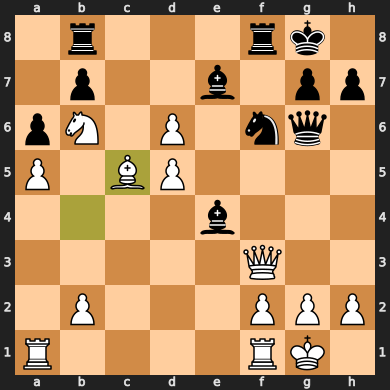

In [ ]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
board.push_uci("e2f3")
board.push_uci("e4f3")
board.push_uci("b3f3")
board.push_uci("f5e4")
board.push_uci("b4c5")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board

move: f1e1, count: 151.0, ev: -0.09640827029943466
move: d6e7, count: 151.0, ev: -0.06172103062272072
move: f1c1, count: 132.0, ev: -0.21057459712028503
move: c5a3, count: 128.0, ev: -0.22966143488883972
move: h2h3, count: 127.0, ev: -0.15094925463199615
move: b6c4, count: 126.0, ev: -0.2122083604335785
move: a1e1, count: 123.0, ev: -0.1638423353433609
move: b6c8, count: 122.0, ev: -0.17765848338603973
move: f1d1, count: 114.0, ev: -0.18012958765029907
move: b2b4, count: 112.0, ev: -0.2240518033504486
move: h2h4, count: 111.0, ev: -0.18335597217082977
move: b6d7, count: 109.0, ev: -0.19115255773067474
move: a1b1, count: 109.0, ev: -0.2397332638502121
move: a1a2, count: 107.0, ev: -0.2594447433948517
move: a1d1, count: 107.0, ev: -0.22422805428504944
move: a1c1, count: 107.0, ev: -0.18694055080413818
move: b2b3, count: 105.0, ev: -0.21338795125484467
move: c5d4, count: 102.0, ev: -0.24992051720619202
move: c5b4, count: 101.0, ev: -0.23275098204612732
move: c5e3, count: 100.0, ev: -0.274

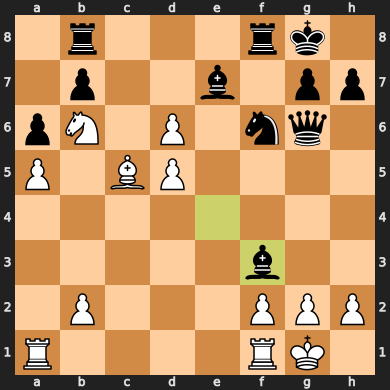

In [ ]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
board.push_uci("e2f3")
board.push_uci("e4f3")
board.push_uci("b3f3")
board.push_uci("f5e4")
board.push_uci("b4c5")
board.push_uci("e4f3")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board

move: g6g2, count: 259.0, ev: 1.0
move: e7d6, count: 183.0, ev: 0.5388139486312866
move: f6e4, count: 122.0, ev: 0.240329772233963
move: f6d5, count: 112.0, ev: 0.21035484969615936
move: b8d8, count: 104.0, ev: 0.0012353165075182915
move: e7d8, count: 103.0, ev: 0.16448648273944855
move: f6g4, count: 100.0, ev: 0.06850285083055496
move: f3g2, count: 94.0, ev: 0.16799992322921753
move: f8c8, count: 91.0, ev: -0.1352301985025406
move: b8e8, count: 91.0, ev: 0.0421808660030365
move: b8c8, count: 86.0, ev: 0.007365052122622728
move: f8f7, count: 84.0, ev: 0.02689450979232788
move: f6h5, count: 84.0, ev: -0.08375655114650726
move: f6d7, count: 83.0, ev: 0.012176710180938244
move: f8e8, count: 77.0, ev: -0.0007770693628117442
move: g6d3, count: 74.0, ev: -0.13939429819583893
move: g8h8, count: 73.0, ev: -0.07537403702735901
move: f8d8, count: 71.0, ev: 0.030573645606637
move: g6h6, count: 71.0, ev: -0.07004854828119278
move: g6g4, count: 71.0, ev: -0.06389449536800385
move: h7h6, count: 71.0

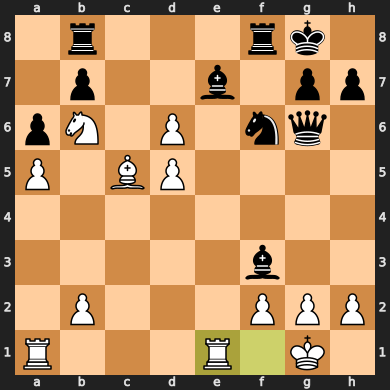

In [ ]:
board = chess.Board("1r3rk1/1p2b1pp/pN1P1nq1/P2P1b2/1B2p3/1Q3p2/1P2BPPP/R4RK1 w - - 1 22")
board.push_uci("e2f3")
board.push_uci("e4f3")
board.push_uci("b3f3")
board.push_uci("f5e4")
board.push_uci("b4c5")
board.push_uci("e4f3")
board.push_uci("f1e1")
print(agent.select_move(game_state=board, num_simulations=sims, temperature=0.0, debug=True, mcts_temperature=mcts_policy_temp))
print("initial eval: ", agent.evaluate_value(board.fen()))
board